In [2]:
from typing import List, Dict, Tuple, Callable, Union
import os, traceback, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns

In [3]:
pip install pybaseball

Note: you may need to restart the kernel to use updated packages.


In [4]:
from pybaseball import lahman
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

In [5]:
def load_batting_data(start_year=2015, end_year=2024, min_pa=200):
    print("Loading Lahman database tables...")
    batting = pd.read_csv("Batting.csv")
    people = pd.read_csv("People.csv")
    people = people[["playerID", "birthYear", "nameFirst", "nameLast"]].copy()
    people["Name"] = people["nameFirst"] + " " + people["nameLast"]
    batting = batting.merge(people, on="playerID", how="left")
    batting["Age"] = batting["yearID"] - batting["birthYear"]
    agg = {
        "AB": "sum", "R": "sum", "H": "sum", "2B": "sum", "3B": "sum",
        "HR": "sum", "RBI": "sum", "SB": "sum", "CS": "sum",
        "BB": "sum", "SO": "sum", "IBB": "sum", "HBP": "sum",
        "SF": "sum", "GIDP": "sum", "G": "sum",
        "Age": "first", "Name": "first",
    batting = (batting.groupby(["playerID", "yearID"], as_index=False)
                      .agg(agg)
                      .rename(columns={"yearID": "Season"}))
    
    # Rate stats
    batting["PA"]    = (batting["AB"] + batting["BB"] + batting["HBP"].fillna(0) + batting["SF"].fillna(0))
    batting["1B"]    = batting["H"] - batting["2B"] - batting["3B"] - batting["HR"]
    batting["AVG"]   = batting["H"]  / batting["AB"].replace(0, np.nan)
    batting["OBP"]   = ((batting["H"] + batting["BB"] + batting["HBP"].fillna(0)) / batting["PA"].replace(0, np.nan))
    batting["SLG"]   = ((batting["1B"] + 2*batting["2B"] + 3*batting["3B"] + 4*batting["HR"]) / batting["AB"].replace(0, np.nan))
    batting["OPS"]   = batting["OBP"] + batting["SLG"]
    batting["ISO"]   = batting["SLG"] - batting["AVG"]
    batting["BB%"]   = batting["BB"] / batting["PA"].replace(0, np.nan)
    batting["K%"]    = batting["SO"] / batting["PA"].replace(0, np.nan)
    batting["BABIP"] = ((batting["H"] - batting["HR"]) / (batting["AB"] - batting["SO"] - batting["HR"] + batting["SF"].fillna(0)).replace(0, np.nan))
    
    wOBA = (0.69  * batting["BB"] +
            0.722  * batting["HBP"].fillna(0) +
            0.888  * batting["1B"] +
            1.271  * batting["2B"] +
            1.616  * batting["3B"] +
            2.101  * batting["HR"]) / batting["PA"].replace(0, np.nan)
    lg_wOBA = 0.320  
    wOBA_scale = 1.15   
    
    batting["wRAA"]  = ((wOBA - lg_wOBA) / wOBA_scale) * batting["PA"]
    repl_runs = (batting["PA"] / 600) * 20 
    batting["WAR"]   = (batting["wRAA"] + repl_runs) / 10.0
    
    batting = batting[
        (batting["Season"] >= start_year) &
        (batting["Season"] <= end_year) &
        (batting["PA"] >= min_pa)
    ].copy()
 
    print(f"Loaded {len(batting)} player-seasons ({start_year}-{end_year}, PA>={min_pa})")
    return batting

In [22]:
FEATURES = ["AVG", "OBP", "SLG", "OPS", "ISO", "BB%", "K%", "BABIP", "HR", "SB", "PA", "G", "WAR", "Age",]
TARGET = "future_WAR"

In [23]:
def engineer_features(df):
    df = df.sort_values(["playerID", "Season"]).reset_index(drop=True)
    df["future_WAR"] = df.groupby("playerID")["WAR"].shift(-1)
    df["AGE_Sqaured"] = df["Age"]**2
    def weighted_WAR(X):
        w1_prev1 = X.shift(1)
        w2_prev2 = X.shift(2)
        w3_prev3 = X.shift(3)
        return (5 * w1_prev1 + 4 * w2_prev2 + 3 * w3_prev3) / 12
    df["Weighted_3yr_WAR"] = (df.groupby("playerID")["WAR"].transform(weighted_WAR))
    df["WAR_trend"] = df["WAR"] - df.groupby("playerID")["WAR"].shift(1)
    global FEATURES
    FEATURES = FEATURES + ["AGE_Sqaured", "Weighted_3yr_WAR", "WAR_trend"]
    return df

In [24]:
def prepare_dataset(df):
    available = [f for f in FEATURES if f in df.columns]
    missing   = [f for f in FEATURES if f not in df.columns]
    if missing:
        print(f"Warning — missing features (skipped): {missing}")
 
    df_clean = df[available + [TARGET, "playerID", "Season", "Name"]].dropna()
    X = df_clean[available].astype(float)
    y = df_clean[TARGET].astype(float)
 
    print(f"\nDataset ready: {len(X)} player-seasons, {X.shape[1]} features")
    print(f"WAR proxy range: {y.min():.1f} – {y.max():.1f}  |  mean: {y.mean():.2f}")
    return X, y, df_clean

In [25]:
def temporal_split(X, y, df_clean, test_season):
    train_mask = df_clean["Season"] < test_season
    test_mask  = df_clean["Season"] == test_season

    if test_mask.sum() == 0:
        raise ValueError(
            f"No rows found for test_season={test_season}. "
            f"Available seasons: {sorted(df_clean['Season'].unique())}"
        )

    return X[train_mask], X[test_mask], y[train_mask], y[test_mask]

In [26]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n{name}")
    print(f"  MAE:  {mae:.3f}")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  R²:   {r2:.3f}")
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

In [27]:
def run_ridge(X_trn, X_tst, y_trn, y_tst):
    print("\n" + "="*50)
    print("MODEL 1: Ridge Regression (Baseline)")
    print("="*50)
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge",  Ridge(alpha=.01))
    ])
    pipeline.fit(X_trn, y_trn)
    y_pred = pipeline.predict(X_tst)
    metrics = evaluate("Ridge Regression", y_tst, y_pred)

    scaler = pipeline.named_steps["scaler"]
    ridge  = pipeline.named_steps["ridge"]
    coef_df = pd.DataFrame({
        "Feature": X_trn.columns,
        "Coefficient": ridge.coef_
    }).sort_values("Coefficient", key=abs, ascending=False)

    mask = y_tst < 5.1
    y_tst_filt  = y_tst[mask]
    y_pred_filt = y_pred[mask]
    X_tst_filt  = X_tst[mask]
    m_filt = evaluate("Ridge Regression", y_tst_filt, y_pred_filt)
    
    print("\nTop 10 coefficients:")
    print(coef_df.head(10).to_string(index=False))
    coef_df_top = coef_df.head(10).sort_values("Coefficient")
    colors = ["#00d4aa" if c > 0 else "#ff6b6b" for c in coef_df_top["Coefficient"]]
    fig, ax = plt.subplots(figsize=(9, 6), facecolor='#0f1117')
    ax.set_facecolor('#0f1117')
    ax.invert_yaxis()
    bars = ax.barh(coef_df_top["Feature"], coef_df_top["Coefficient"], color=colors, alpha=0.85, height=0.6, zorder=3)
    ax.barh(coef_df_top["Feature"], coef_df_top["Coefficient"], color=colors, alpha=0.15, height=0.75, zorder=2)
    ax.axvline(0, color='#ffffff', linewidth=0.8, alpha=0.4, zorder=4)
    ax.grid(axis='x', color='#ffffff', linestyle='--', linewidth=0.4, alpha=0.12)
    ax.set_axisbelow(True)
    ax.tick_params(colors='#8892a4', labelsize=10)
    ax.set_yticklabels(coef_df_top["Feature"], fontfamily='monospace', color='#c9d1d9', fontsize=10)
    ax.set_xticklabels(ax.get_xticks(), fontfamily='monospace', color='#8892a4')
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2f3d')
    ax.set_xlabel("Coefficient Value", fontsize=12, color='#c9d1d9', labelpad=10, fontfamily='monospace')
    ax.set_title("Ridge — Top 10 Feature Coefficients", fontsize=16, color='#ffffff', fontfamily='monospace', fontweight='bold', pad=18)
    ax.invert_yaxis()
    pos_patch = mpatches.Patch(color='#00d4aa', label='Positive')
    neg_patch = mpatches.Patch(color='#ff6b6b', label='Negative')
    ax.legend(handles=[pos_patch, neg_patch], facecolor='#1c2030', edgecolor='#2a2f3d', labelcolor='#c9d1d9', fontsize=10)
    plt.tight_layout()
    plt.show()

    residuals = y_tst - y_pred
    fig, ax = plt.subplots(figsize=(8, 5), facecolor='#0f1117')
    ax.set_facecolor('#0f1117')
    counts, bin_edges = np.histogram(residuals, bins=30)
    for i in range(len(counts)):
        color = '#00d4aa' if (bin_edges[i] + bin_edges[i+1]) / 2 >= 0 else '#ff6b6b'
        ax.bar(bin_edges[i], counts[i], width=bin_edges[i+1] - bin_edges[i], color=color, alpha=0.85, zorder=3, align='edge')
        ax.bar(bin_edges[i], counts[i], width=bin_edges[i+1] - bin_edges[i], color=color, alpha=0.15, zorder=2, align='edge')
    ax.axvline(0, color='#ffffff', linewidth=0.8, alpha=0.4, zorder=4)
    ax.grid(axis='y', color='#ffffff', linestyle='--', linewidth=0.4, alpha=0.12)
    ax.set_axisbelow(True)
    ax.tick_params(colors='#8892a4', labelsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2f3d')
    ax.set_xlabel("Residual", fontsize=12, color='#c9d1d9', labelpad=10, fontfamily='monospace')
    ax.set_ylabel("Count", fontsize=12, color='#c9d1d9', labelpad=10, fontfamily='monospace')
    ax.set_title("Ridge — Distribution of Residuals", fontsize=16, color='#ffffff', fontfamily='monospace', fontweight='bold', pad=18)
    pos_patch = mpatches.Patch(color='#00d4aa', label='Overestimated')
    neg_patch = mpatches.Patch(color='#ff6b6b', label='Underestimated')
    ax.legend(handles=[pos_patch, neg_patch], facecolor='#1c2030', edgecolor='#2a2f3d', labelcolor='#c9d1d9', fontsize=10)
    
    return pipeline, y_pred, metrics, y_pred_filt, m_filt

In [28]:
def ridge_models():
    fig, ax = plt.subplots(figsize=(7, 7), facecolor='#0f1117')
    ax.set_facecolor('#0f1117')
    ax.grid(color='#ff7fff', linestyle='--', linewidth=0.4, alpha=0.12)
    ax.set_axisbelow(True)
    ax.scatter(y_tst, ridge_preds, s=90, color='#00d4aa', alpha=0.18, linewidths=0, zorder=3) 
    ax.scatter(y_tst, ridge_preds, s=45, color='#00d4fa', alpha=0.85, linewidths=0.5, edgecolors='#00ffcc', zorder=4)
    ax.plot([-2, 13], [-2, 13], color='#ff6b6b', linewidth=1.5, linestyle='--', alpha=0.6, label='Perfect Prediction', zorder=5)
    ax.set_xlim(-2, 13)
    ax.set_ylim(-2, 13)
    ax.tick_params(colors='#8892a4', labelsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2f3d')
    ax.set_xlabel("Actual WAR", fontsize=12, color='#c9d1d9', labelpad=10, fontfamily='monospace')
    ax.set_ylabel("Predicted WAR", fontsize=12, color='#c9d1d9', labelpad=10, fontfamily='monospace')
    ax.set_title("Predicted vs Actual WAR", fontsize=16, color='#ffffff', fontfamily='monospace', fontweight='bold', pad=18)
    line_patch = mpatches.Patch(color='#ff6b6b', alpha=0.6, label='Perfect Prediction')
    dot_patch = mpatches.Patch(color='#00d4aa', label='Ridge Predictions')
    ax.axhline(0, color='#ffffff', linewidth=0.8, alpha=0.3, zorder=2)
    ax.axvline(0, color='#ffffff', linewidth=0.8, alpha=0.3, zorder=2)
    ax.legend(handles=[line_patch, dot_patch], facecolor='#1c2030', edgecolor='#2a2f3d', labelcolor='#c9d1d9', fontsize=10)
    plt.tight_layout()
    plt.show()




    distances = np.abs(np.array(ridge_preds) - np.array(y_tst)) / np.sqrt(2)
    norm = mcolors.Normalize(vmin=distances.min(), vmax=distances.max())
    cmap = plt.cm.RdYlBu_r  
    colors = cmap(norm(distances))
    fig, ax = plt.subplots(figsize=(7, 7), facecolor='#0f1117')
    ax.set_facecolor('#0f1117')
    ax.grid(color='#ff7fff', linestyle='--', linewidth=0.4, alpha=0.12)
    ax.set_axisbelow(True)
    ax.scatter(y_tst, ridge_preds, s=90, c=colors, alpha=0.2, linewidths=0, zorder=3)
    ax.scatter(y_tst, ridge_preds, s=45, c=colors, alpha=0.9, linewidths=0.5, edgecolors='#ffffff22', zorder=4)
    ax.plot([-2, 13], [-2, 13], color='#ff6b6b', linewidth=1.5, linestyle='--', alpha=0.6, label='Perfect Prediction', zorder=5)
    ax.set_xlim(-2, 13)
    ax.set_ylim(-2, 13)
    ax.tick_params(colors='#8892a4', labelsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2f3d')
    ax.set_xlabel("Actual WAR", fontsize=12, color='#c9d1d9', labelpad=10, fontfamily='monospace')
    ax.set_ylabel("Predicted WAR", fontsize=12, color='#c9d1d9', labelpad=10, fontfamily='monospace')
    ax.set_title("Predicted vs Actual WAR", fontsize=16, color='#ffffff', fontfamily='monospace', fontweight='bold', pad=18)
    ax.axhline(0, color='#ffffff', linewidth=0.8, alpha=0.3, zorder=2)
    ax.axvline(0, color='#ffffff', linewidth=0.8, alpha=0.3, zorder=2)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label('Distance from Perfect Prediction', color='#c9d1d9', fontsize=9, fontfamily='monospace')
    cbar.ax.yaxis.set_tick_params(color='#8892a4')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#8892a4', fontfamily='monospace')
    cbar.outline.set_edgecolor('#2a2f3d')
    plt.tight_layout()
    plt.show()



    grid_x = np.linspace(-2, 13, 400)
    grid_y = np.linspace(-2, 13, 400)
    XX, YY = np.meshgrid(grid_x, grid_y)
    ZZ = np.abs(YY - XX) / np.sqrt(2)
    fig, ax = plt.subplots(figsize=(7, 7), facecolor='#0f1117')
    ax.set_facecolor('#0f1117')
    max_dist = np.abs(np.array(ridge_preds) - np.array(y_tst)).max() / np.sqrt(2)
    heatmap = ax.pcolormesh(XX, YY, ZZ, cmap='RdYlBu_r', shading='auto', 
                            norm=mcolors.Normalize(vmin=0, vmax=max_dist))
    ax.plot([-2, 13], [-2, 13], color='white', linewidth=1.5, linestyle='--', alpha=0.8, 
            label='Perfect Prediction', zorder=5)
    ax.set_xlim(-2, 13)
    ax.set_ylim(-2, 13)
    ax.tick_params(colors='#8892a4', labelsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2f3d')
    ax.set_xlabel("Actual WAR", fontsize=12, color='#c9d1d9', labelpad=10, fontfamily='monospace')
    ax.set_ylabel("Predicted WAR", fontsize=12, color='#c9d1d9', labelpad=10, fontfamily='monospace')
    ax.set_title("Predicted vs Actual WAR", fontsize=16, color='#ffffff', fontfamily='monospace', fontweight='bold', pad=18)
    ax.axhline(0, color='#ffffff', linewidth=0.8, alpha=0.3, zorder=2)
    ax.axvline(0, color='#ffffff', linewidth=0.8, alpha=0.3, zorder=2)
    cbar = plt.colorbar(heatmap, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label('Distance from Perfect Prediction', color='#c9d1d9', fontsize=9, fontfamily='monospace')
    cbar.ax.yaxis.set_tick_params(color='#8892a4')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#8892a4', fontfamily='monospace')
    cbar.outline.set_edgecolor('#2a2f3d')
    plt.tight_layout()
    plt.show()


    residuals = np.array(y_tst) - np.array(ridge_preds)
    mask = np.abs(residuals) >= 3
    y_tst_arr = np.array(y_tst)
    ridge_preds_arr = np.array(ridge_preds)
    outliers_x = y_tst_arr[mask]
    outliers_y = ridge_preds_arr[mask]
    reg = LinearRegression()
    reg.fit(outliers_x.reshape(-1, 1), outliers_y)
    x_line = np.linspace(outliers_x.min(), outliers_x.max(), 200)
    y_line = reg.predict(x_line.reshape(-1, 1))
    distances = np.abs(outliers_y - outliers_x) / np.sqrt(2)
    norm = mcolors.Normalize(vmin=distances.min(), vmax=distances.max())
    cmap = plt.cm.RdYlBu_r
    colors = cmap(norm(distances))
    fig, ax = plt.subplots(figsize=(7, 7), facecolor='#0f1117')
    ax.set_facecolor('#0f1117')
    ax.grid(color='#ffffff', linestyle='--', linewidth=0.4, alpha=0.12)
    ax.set_axisbelow(True)
    ax.plot([-2, 13], [-2, 13], color='#ff6b6b', linewidth=1.5, linestyle='--', alpha=0.6, label='Perfect Prediction', zorder=5)
    ax.scatter(outliers_x, outliers_y, s=90, c=colors, alpha=0.2, linewidths=0, zorder=3)
    ax.scatter(outliers_x, outliers_y, s=45, c=colors, alpha=0.9, linewidths=0.5, edgecolors='#ffffff22', zorder=4)
    ax.plot(x_line, y_line, color='#ffffff', linewidth=1.8, linestyle='-', alpha=0.85, label='Outlier Trend', zorder=6)
    ax.set_xlim(-2, 13)
    ax.set_ylim(-2, 13)
    ax.tick_params(colors='#8892a4', labelsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2f3d')
    ax.set_xlabel("Actual WAR", fontsize=12, color='#c9d1d9', labelpad=10, fontfamily='monospace')
    ax.set_ylabel("Predicted WAR", fontsize=12, color='#c9d1d9', labelpad=10, fontfamily='monospace')
    ax.set_title("Outliers (≥3 WAR Error) — Trend Line", fontsize=16, color='#ffffff', fontfamily='monospace', fontweight='bold', pad=18)
    ax.axhline(0, color='#ffffff', linewidth=0.8, alpha=0.3, zorder=2)
    ax.axvline(0, color='#ffffff', linewidth=0.8, alpha=0.3, zorder=2)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label('Distance from Perfect Prediction', color='#c9d1d9', fontsize=9, fontfamily='monospace')
    cbar.ax.yaxis.set_tick_params(color='#8892a4')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#8892a4', fontfamily='monospace')
    cbar.outline.set_edgecolor('#2a2f3d')
    ax.legend(facecolor='#1c2030', edgecolor='#2a2f3d', labelcolor='#c9d1d9', fontsize=10)
    plt.tight_layout()
    plt.show()
    print(f"Outlier count: {mask.sum()} / {len(y_tst)} points ({mask.mean()*100:.1f}%)")
    print(f"Slope: {reg.coef_[0]:.3f} | Intercept: {reg.intercept_:.3f} | R²: {reg.score(outliers_x.reshape(-1,1), outliers_y):.3f}")


    """    
    outliers_x = np.array(y_tst)[mask]
    outliers_y = np.array(ridge_preds)[mask]
    outliers_res = residuals[mask]
    under_x = outliers_x[outliers_res > 0]  
    over_x = outliers_x[outliers_res < 0]   
    first_under = under_x.min()  
    first_over = over_x.max()   
    reg = LinearRegression()
    reg.fit(outliers_x.reshape(-1, 1), outliers_y)
    x_line = np.linspace(outliers_x.min(), outliers_x.max(), 200)
    y_line = reg.predict(x_line.reshape(-1, 1))
    distances = np.abs(outliers_y - outliers_x) / np.sqrt(2)
    norm = mcolors.Normalize(vmin=distances.min(), vmax=distances.max())
    cmap = plt.cm.RdYlBu_r
    colors = cmap(norm(distances))
    fig, ax = plt.subplots(figsize=(7, 7), facecolor='#0f1117')
    ax.set_facecolor('#0f1117')
    ax.grid(color='#ffffff', linestyle='--', linewidth=0.4, alpha=0.12)
    ax.set_axisbelow(True)
    ax.plot([-2, 13], [-2, 13], color='#ff6b6b', linewidth=1.5,
            linestyle='--', alpha=0.6, label='Perfect Prediction', zorder=5)
    ax.scatter(outliers_x, outliers_y, s=90, c=colors, alpha=0.2,
               linewidths=0, zorder=3)
    ax.scatter(outliers_x, outliers_y, s=45, c=colors, alpha=0.9,
               linewidths=0.5, edgecolors='#ffffff22', zorder=4)
    ax.axvline(first_under, color='#00d4aa', linewidth=1.2, linestyle='--',
               alpha=0.8, zorder=6, label=f'First Underpredict (WAR={first_under:.1f})')
    ax.axvline(first_over, color='#c77dff', linewidth=1.2, linestyle='--',
               alpha=0.8, zorder=6, label=f'First Overpredict (WAR={first_over:.1f})')
    ax.text(first_under + 0.2, -1.5, f'Under\n{first_under:.1f}',
            color='#00d4aa', fontsize=8, fontfamily='monospace', alpha=0.9)
    ax.text(first_over + 0.2, -1.5, f'Over\n{first_over:.1f}',
            color='#c77dff', fontsize=8, fontfamily='monospace', alpha=0.9)
    ax.set_xlim(-2, 13)
    ax.set_ylim(-2, 13)
    ax.tick_params(colors='#8892a4', labelsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2f3d')
    ax.set_xlabel("Actual WAR", fontsize=12, color='#c9d1d9',
                  labelpad=10, fontfamily='monospace')
    ax.set_ylabel("Predicted WAR", fontsize=12, color='#c9d1d9',
                  labelpad=10, fontfamily='monospace')
    ax.set_title("Outliers with Prediction Boundaries", fontsize=16,
                 color='#ffffff', fontfamily='monospace', fontweight='bold', pad=18)
    ax.axhline(0, color='#ffffff', linewidth=0.8, alpha=0.3, zorder=2)
    ax.axvline(0, color='#ffffff', linewidth=0.8, alpha=0.3, zorder=2)
    ax.legend(facecolor='#1c2030', edgecolor='#2a2f3d',
              labelcolor='#c9d1d9', fontsize=9)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label('Distance from Perfect Prediction', color='#c9d1d9',
                   fontsize=9, fontfamily='monospace')
    cbar.ax.yaxis.set_tick_params(color='#8892a4')
    ax.axvspan(first_over, first_under, color='#ffffff', alpha=0.05, zorder=1)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#8892a4', fontfamily='monospace')
    cbar.outline.set_edgecolor('#2a2f3d')
    plt.tight_layout()
    plt.show()


    plt.tight_layout()
    plt.show()
    """

In [29]:
def run_rf(X_train, X_test, y_train, y_test):
    print("\n" + "="*50 + "\nMODEL: RANDOM FOREST (2-STAGE)\n" + "="*50)
    elite_train = (y_train >= 5).astype(int)

    clf = RandomForestClassifier(
        n_estimators=500,
        max_depth=6,
        class_weight={0: 1, 1: 3},
        random_state=42
    )
    clf.fit(X_train, elite_train)
    from sklearn.calibration import CalibratedClassifierCV
    clf_cal = CalibratedClassifierCV(clf, cv=5, method='isotonic')
    clf_cal.fit(X_train, elite_train)
    elite_prob = clf_cal.predict_proba(X_test)[:, 1]

    rf_normal = RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=5,
        max_features=0.6,
        random_state=42
    )
    rf_normal.fit(X_train, y_train)


    mask = y_train >= 4

    rf_elite = RandomForestRegressor(
        n_estimators=1000,
        max_depth=None,
        min_samples_leaf=3,
        max_features=0.7,
        random_state=42
    )
    rf_elite.fit(X_train[mask], y_train[mask])

    y_pred_normal = rf_normal.predict(X_test)
    y_pred_elite  = rf_elite.predict(X_test)
    alpha = np.where(elite_prob > 0.25, elite_prob, 0.0)
    y_pred = alpha * y_pred_elite + (1 - alpha) * y_pred_normal
    boost_mask = y_pred > 4.5
    y_pred[boost_mask] = y_pred[boost_mask] * (1 + 0.12 * (y_pred[boost_mask] / 5))
    mid_mask  = (y_pred >= 3.5) & (y_pred < 6.0)
    high_mask = y_pred >= 6.0
    y_pred[mid_mask]  = y_pred[mid_mask]  * 1.12
    y_pred[high_mask] = y_pred[high_mask] * 1.18


    train_max = y_train.max()
    pred_max  = y_pred.max()
    
    if pred_max < train_max * 0.8: 
        stretch_mask = y_pred > np.percentile(y_pred, 95)
        y_pred[stretch_mask] = y_pred[stretch_mask] * (train_max / pred_max) * 0.90
    revert_mask = (y_pred_normal < 1.0) & (y_pred > 3.0)
    y_pred[revert_mask] = y_pred_normal[revert_mask] * 1.05
    metrics = evaluate("Random Forest (2-stage)", y_test, y_pred)

    return y_pred, metrics, y_pred

In [30]:
def rf_models():
    fig, ax = plt.subplots(figsize=(7, 7), facecolor='#0f1117')
    ax.set_facecolor('#0f1117')
    ax.grid(color='#ff7fff', linestyle='--', linewidth=0.4, alpha=0.12)
    ax.set_axisbelow(True)
    ax.scatter(y_tst, rf_preds, s=90, color='#00d4aa', alpha=0.18,
               linewidths=0, zorder=3)  # halo
    ax.scatter(y_tst, rf_preds, s=45, color='#00d4fa', alpha=0.85,
               linewidths=0.5, edgecolors='#00ffcc', zorder=4)
    ax.plot([-2, 13], [-2, 13], color='#ff6b6b', linewidth=1.5,
            linestyle='--', alpha=0.6, label='Perfect Prediction', zorder=5)
    ax.set_xlim(-2, 13)
    ax.set_ylim(-2, 13)
    ax.tick_params(colors='#8892a4', labelsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2f3d')
    ax.set_xlabel("Actual WAR", fontsize=12, color='#c9d1d9',
                  labelpad=10, fontfamily='monospace')
    ax.set_ylabel("Predicted WAR", fontsize=12, color='#c9d1d9',
                  labelpad=10, fontfamily='monospace')
    ax.set_title("Predicted vs Actual WAR", fontsize=16, color='#ffffff',
                 fontfamily='monospace', fontweight='bold', pad=18)
    line_patch = mpatches.Patch(color='#ff6b6b', alpha=0.6, label='Perfect Prediction')
    dot_patch = mpatches.Patch(color='#00d4aa', label='RF Predictions')
    ax.axhline(0, color='#ffffff', linewidth=0.8, alpha=0.3, zorder=2)
    ax.axvline(0, color='#ffffff', linewidth=0.8, alpha=0.3, zorder=2)
    ax.legend(handles=[line_patch, dot_patch], facecolor='#1c2030',
              edgecolor='#2a2f3d', labelcolor='#c9d1d9', fontsize=10)
    plt.tight_layout()
    plt.show()




    distances = np.abs(np.array(rf_preds) - np.array(y_tst)) / np.sqrt(2)
    norm = mcolors.Normalize(vmin=distances.min(), vmax=distances.max())
    cmap = plt.cm.RdYlBu_r  
    colors = cmap(norm(distances))
    fig, ax = plt.subplots(figsize=(7, 7), facecolor='#0f1117')
    ax.set_facecolor('#0f1117')
    ax.grid(color='#ff7fff', linestyle='--', linewidth=0.4, alpha=0.12)
    ax.set_axisbelow(True)
    ax.scatter(y_tst, rf_preds, s=90, c=colors, alpha=0.2,
               linewidths=0, zorder=3)
    ax.scatter(y_tst, rf_preds, s=45, c=colors, alpha=0.9,
               linewidths=0.5, edgecolors='#ffffff22', zorder=4)
    ax.plot([-2, 13], [-2, 13], color='#ff6b6b', linewidth=1.5,
            linestyle='--', alpha=0.6, label='Perfect Prediction', zorder=5)
    ax.set_xlim(-2, 13)
    ax.set_ylim(-2, 13)
    ax.tick_params(colors='#8892a4', labelsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2f3d')
    ax.set_xlabel("Actual WAR", fontsize=12, color='#c9d1d9',
                  labelpad=10, fontfamily='monospace')
    ax.set_ylabel("Predicted WAR", fontsize=12, color='#c9d1d9',
                  labelpad=10, fontfamily='monospace')
    ax.set_title("Predicted vs Actual WAR", fontsize=16, color='#ffffff',
                 fontfamily='monospace', fontweight='bold', pad=18)
    ax.axhline(0, color='#ffffff', linewidth=0.8, alpha=0.3, zorder=2)
    ax.axvline(0, color='#ffffff', linewidth=0.8, alpha=0.3, zorder=2)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label('Distance from Perfect Prediction', color='#c9d1d9',
                   fontsize=9, fontfamily='monospace')
    cbar.ax.yaxis.set_tick_params(color='#8892a4')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#8892a4', fontfamily='monospace')
    cbar.outline.set_edgecolor('#2a2f3d')
    plt.tight_layout()
    plt.show()



    grid_x = np.linspace(-2, 13, 400)
    grid_y = np.linspace(-2, 13, 400)
    XX, YY = np.meshgrid(grid_x, grid_y)
    ZZ = np.abs(YY - XX) / np.sqrt(2)
    fig, ax = plt.subplots(figsize=(7, 7), facecolor='#0f1117')
    ax.set_facecolor('#0f1117')
    max_dist = np.abs(np.array(rf_preds) - np.array(y_tst)).max() / np.sqrt(2)

    heatmap = ax.pcolormesh(XX, YY, ZZ, cmap='RdYlBu_r', shading='auto',
                             norm=mcolors.Normalize(vmin=0, vmax=max_dist))
    ax.plot([-2, 13], [-2, 13], color='white', linewidth=1.5,
            linestyle='--', alpha=0.8, label='Perfect Prediction', zorder=5)
    ax.set_xlim(-2, 13)
    ax.set_ylim(-2, 13)
    ax.tick_params(colors='#8892a4', labelsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2f3d')
    ax.set_xlabel("Actual WAR", fontsize=12, color='#c9d1d9',
                  labelpad=10, fontfamily='monospace')
    ax.set_ylabel("Predicted WAR", fontsize=12, color='#c9d1d9',
                  labelpad=10, fontfamily='monospace')
    ax.set_title("Predicted vs Actual WAR", fontsize=16, color='#ffffff',
                 fontfamily='monospace', fontweight='bold', pad=18)
    ax.axhline(0, color='#ffffff', linewidth=0.8, alpha=0.3, zorder=2)
    ax.axvline(0, color='#ffffff', linewidth=0.8, alpha=0.3, zorder=2)
    cbar = plt.colorbar(heatmap, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label('Distance from Perfect Prediction', color='#c9d1d9',
                   fontsize=9, fontfamily='monospace')
    cbar.ax.yaxis.set_tick_params(color='#8892a4')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#8892a4', fontfamily='monospace')
    cbar.outline.set_edgecolor('#2a2f3d')
    plt.tight_layout()
    plt.show()

    """
    # Filter points where prediction is off by 2 or more
    residuals = np.array(y_tst) - np.array(rf_preds)
    mask = np.abs(residuals) >= 3
    y_tst_arr = np.array(y_tst)
    rf_preds_arr = np.array(rf_preds)
    outliers_x = y_tst_arr[mask]
    outliers_y = rf_preds_arr[mask]
    # Fit linear regression through the outlier points
    reg = LinearRegression()
    reg.fit(outliers_x.reshape(-1, 1), outliers_y)
    x_line = np.linspace(outliers_x.min(), outliers_x.max(), 200)
    y_line = reg.predict(x_line.reshape(-1, 1))
    # Plot
    distances = np.abs(outliers_y - outliers_x) / np.sqrt(2)
    norm = mcolors.Normalize(vmin=distances.min(), vmax=distances.max())
    cmap = plt.cm.RdYlBu_r
    colors = cmap(norm(distances))
    fig, ax = plt.subplots(figsize=(7, 7), facecolor='#0f1117')
    ax.set_facecolor('#0f1117')
    ax.grid(color='#ffffff', linestyle='--', linewidth=0.4, alpha=0.12)
    ax.set_axisbelow(True)
    # Perfect prediction line
    ax.plot([-2, 13], [-2, 13], color='#ff6b6b', linewidth=1.5,
            linestyle='--', alpha=0.6, label='Perfect Prediction', zorder=5)
    ax.scatter(outliers_x, outliers_y, s=90, c=colors, alpha=0.2,
               linewidths=0, zorder=3)
    ax.scatter(outliers_x, outliers_y, s=45, c=colors, alpha=0.9,
               linewidths=0.5, edgecolors='#ffffff22', zorder=4)
    ax.plot(x_line, y_line, color='#ffffff', linewidth=1.8,
            linestyle='-', alpha=0.85, label='Outlier Trend', zorder=6)
    ax.set_xlim(-2, 13)
    ax.set_ylim(-2, 13)
    ax.tick_params(colors='#8892a4', labelsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2f3d')
    ax.set_xlabel("Actual WAR", fontsize=12, color='#c9d1d9',
                  labelpad=10, fontfamily='monospace')
    ax.set_ylabel("Predicted WAR", fontsize=12, color='#c9d1d9',
                  labelpad=10, fontfamily='monospace')
    ax.set_title("Outliers (≥3 WAR Error) — Trend Line", fontsize=16, color='#ffffff',
                 fontfamily='monospace', fontweight='bold', pad=18)
    ax.axhline(0, color='#ffffff', linewidth=0.8, alpha=0.3, zorder=2)
    ax.axvline(0, color='#ffffff', linewidth=0.8, alpha=0.3, zorder=2)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label('Distance from Perfect Prediction', color='#c9d1d9',
                   fontsize=9, fontfamily='monospace')
    cbar.ax.yaxis.set_tick_params(color='#8892a4')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#8892a4', fontfamily='monospace')
    cbar.outline.set_edgecolor('#2a2f3d')
    ax.legend(facecolor='#1c2030', edgecolor='#2a2f3d',
              labelcolor='#c9d1d9', fontsize=10)
    plt.tight_layout()
    plt.show()
    print(f"Outlier count: {mask.sum()} / {len(y_tst)} points ({mask.mean()*100:.1f}%)")
    print(f"Slope: {reg.coef_[0]:.3f} | Intercept: {reg.intercept_:.3f} | R²: {reg.score(outliers_x.reshape(-1,1), outliers_y):.3f}")


    
    outliers_x = np.array(y_tst)[mask]
    outliers_y = np.array(rf_preds)[mask]
    outliers_res = residuals[mask]
    under_x = outliers_x[outliers_res > 0]  
    over_x = outliers_x[outliers_res < 0]   
    first_under = under_x.min()  
    first_over = over_x.max()   
    reg = LinearRegression()
    reg.fit(outliers_x.reshape(-1, 1), outliers_y)
    x_line = np.linspace(outliers_x.min(), outliers_x.max(), 200)
    y_line = reg.predict(x_line.reshape(-1, 1))
    distances = np.abs(outliers_y - outliers_x) / np.sqrt(2)
    norm = mcolors.Normalize(vmin=distances.min(), vmax=distances.max())
    cmap = plt.cm.RdYlBu_r
    colors = cmap(norm(distances))
    fig, ax = plt.subplots(figsize=(7, 7), facecolor='#0f1117')
    ax.set_facecolor('#0f1117')
    ax.grid(color='#ffffff', linestyle='--', linewidth=0.4, alpha=0.12)
    ax.set_axisbelow(True)
    ax.plot([-2, 13], [-2, 13], color='#ff6b6b', linewidth=1.5,
            linestyle='--', alpha=0.6, label='Perfect Prediction', zorder=5)
    ax.scatter(outliers_x, outliers_y, s=90, c=colors, alpha=0.2,
               linewidths=0, zorder=3)
    ax.scatter(outliers_x, outliers_y, s=45, c=colors, alpha=0.9,
               linewidths=0.5, edgecolors='#ffffff22', zorder=4)
    ax.axvline(first_under, color='#00d4aa', linewidth=1.2, linestyle='--',
               alpha=0.8, zorder=6, label=f'First Underpredict (WAR={first_under:.1f})')
    ax.axvline(first_over, color='#c77dff', linewidth=1.2, linestyle='--',
               alpha=0.8, zorder=6, label=f'First Overpredict (WAR={first_over:.1f})')
    ax.text(first_under + 0.2, -1.5, f'Under\n{first_under:.1f}',
            color='#00d4aa', fontsize=8, fontfamily='monospace', alpha=0.9)
    ax.text(first_over + 0.2, -1.5, f'Over\n{first_over:.1f}',
            color='#c77dff', fontsize=8, fontfamily='monospace', alpha=0.9)
    ax.set_xlim(-2, 13)
    ax.set_ylim(-2, 13)
    ax.tick_params(colors='#8892a4', labelsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2f3d')
    ax.set_xlabel("Actual WAR", fontsize=12, color='#c9d1d9',
                  labelpad=10, fontfamily='monospace')
    ax.set_ylabel("Predicted WAR", fontsize=12, color='#c9d1d9',
                  labelpad=10, fontfamily='monospace')
    ax.set_title("Outliers with Prediction Boundaries", fontsize=16,
                 color='#ffffff', fontfamily='monospace', fontweight='bold', pad=18)
    ax.axhline(0, color='#ffffff', linewidth=0.8, alpha=0.3, zorder=2)
    ax.axvline(0, color='#ffffff', linewidth=0.8, alpha=0.3, zorder=2)
    ax.legend(facecolor='#1c2030', edgecolor='#2a2f3d',
              labelcolor='#c9d1d9', fontsize=9)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label('Distance from Perfect Prediction', color='#c9d1d9',
                   fontsize=9, fontfamily='monospace')
    cbar.ax.yaxis.set_tick_params(color='#8892a4')
    ax.axvspan(first_over, first_under, color='#ffffff', alpha=0.05, zorder=1)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#8892a4', fontfamily='monospace')
    cbar.outline.set_edgecolor('#2a2f3d')
    plt.tight_layout()
    plt.show()


    plt.tight_layout()
    plt.show()
    """

In [31]:
def blended_models():
    fig, ax = plt.subplots(figsize=(7, 7), facecolor='#0f1117')
    ax.set_facecolor('#0f1117')
    ax.grid(color='#ff7fff', linestyle='--', linewidth=0.4, alpha=0.12)
    ax.set_axisbelow(True)
    ax.scatter(y_tst, blended_preds, s=90, color='#00d4aa', alpha=0.18,
               linewidths=0, zorder=3)  # halo
    ax.scatter(y_tst, blended_preds, s=45, color='#00d4fa', alpha=0.85,
               linewidths=0.5, edgecolors='#00ffcc', zorder=4)
    ax.plot([-2, 13], [-2, 13], color='#ff6b6b', linewidth=1.5,
            linestyle='--', alpha=0.6, label='Perfect Prediction', zorder=5)
    ax.set_xlim(-2, 13)
    ax.set_ylim(-2, 13)
    ax.tick_params(colors='#8892a4', labelsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2f3d')
    ax.set_xlabel("Actual WAR", fontsize=12, color='#c9d1d9',
                  labelpad=10, fontfamily='monospace')
    ax.set_ylabel("Predicted WAR", fontsize=12, color='#c9d1d9',
                  labelpad=10, fontfamily='monospace')
    ax.set_title("Predicted vs Actual WAR", fontsize=16, color='#ffffff',
                 fontfamily='monospace', fontweight='bold', pad=18)
    line_patch = mpatches.Patch(color='#ff6b6b', alpha=0.6, label='Perfect Prediction')
    dot_patch = mpatches.Patch(color='#00d4aa', label= 'Blended Predictions')
    ax.axhline(0, color='#ffffff', linewidth=0.8, alpha=0.3, zorder=2)
    ax.axvline(0, color='#ffffff', linewidth=0.8, alpha=0.3, zorder=2)
    ax.legend(handles=[line_patch, dot_patch], facecolor='#1c2030',
              edgecolor='#2a2f3d', labelcolor='#c9d1d9', fontsize=10)
    plt.tight_layout()
    plt.show()
    

Loading Lahman database tables...
Loaded 2969 player-seasons (2015-2023, PA>=200)

Dataset ready: 628 player-seasons, 26 features
WAR proxy range: -2.0 – 11.2  |  mean: 2.23

MODEL 1: Ridge Regression (Baseline)

Ridge Regression
  MAE:  1.325
  RMSE: 1.799
  R²:   0.342

Ridge Regression
  MAE:  1.060
  RMSE: 1.301
  R²:   0.358

Top 10 coefficients:
    Feature  Coefficient
        Age    -1.712711
        AVG    -0.546173
        WAR     0.534797
         HR    -0.388876
      BABIP     0.374902
AGE_Sqaured     0.349985
AGE_Sqaured     0.349985
AGE_Sqaured     0.349985
AGE_Sqaured     0.349985
          G    -0.345195


C:\Users\jacks\AppData\Local\Temp\ipykernel_31460\4267639246.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(coef_df_top["Feature"], fontfamily='monospace',
C:\Users\jacks\AppData\Local\Temp\ipykernel_31460\4267639246.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontfamily='monospace', color='#8892a4')


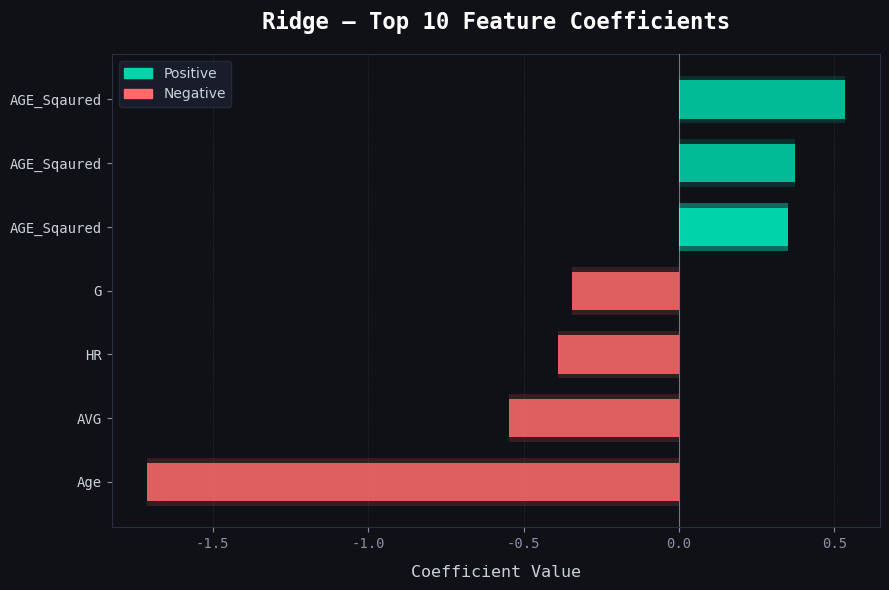

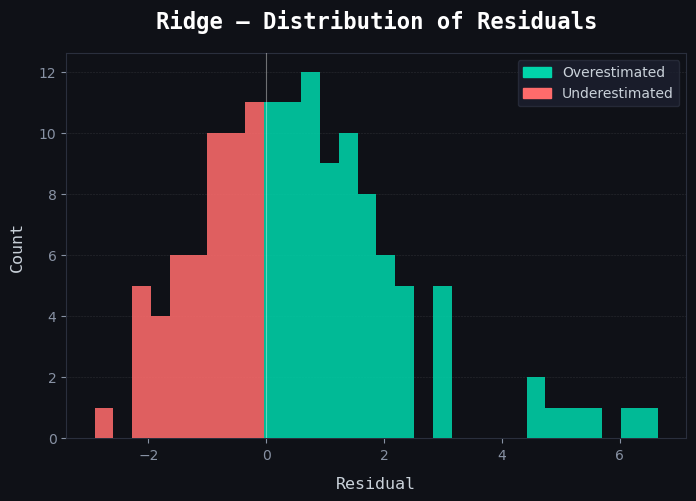

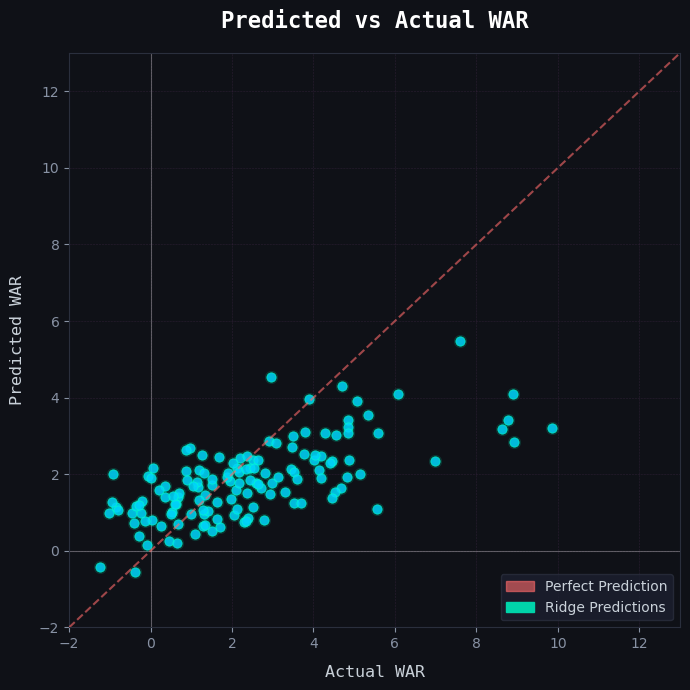

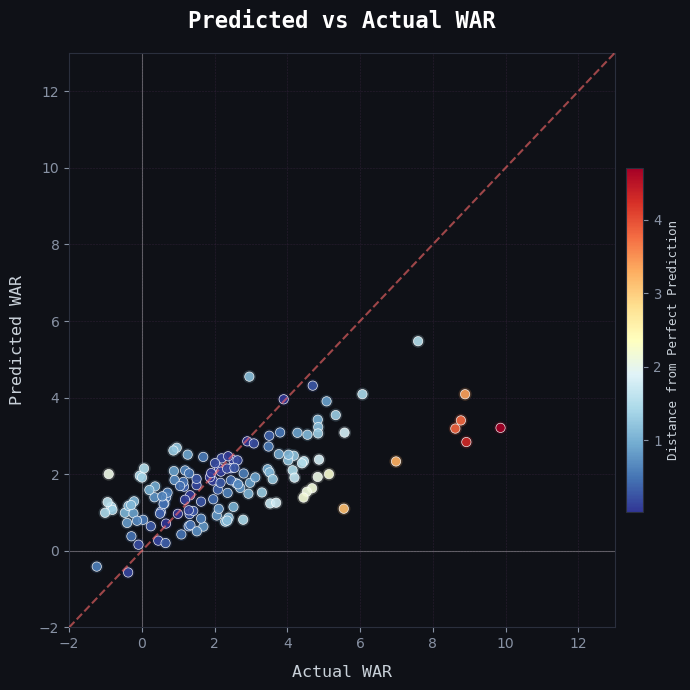

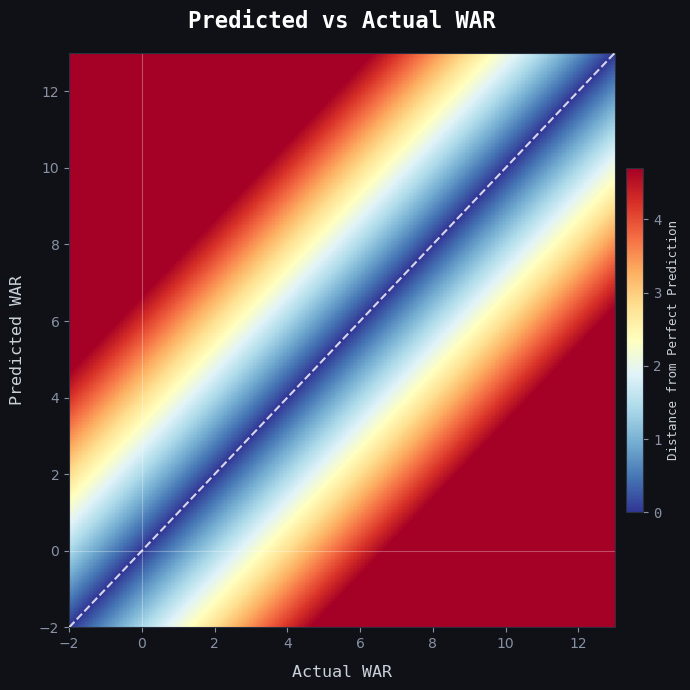

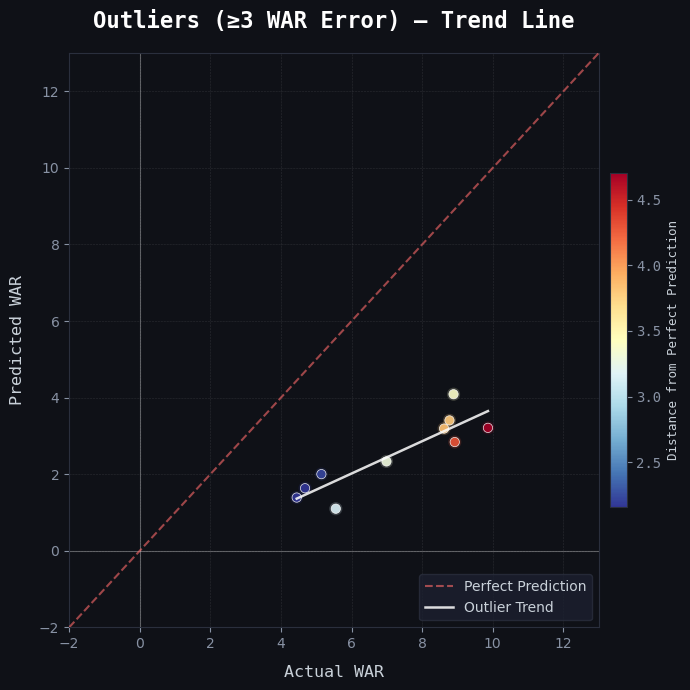

Outlier count: 10 / 137 points (7.3%)
Slope: 0.422 | Intercept: -0.515 | R²: 0.788
Actual WAR range: -1.2400869565217403 9.862521739130434
Predicted WAR range: -0.5655877991562517 5.473823592305479
Mean Actual WAR: 2.407095525230085
Mean Predicted WAR: 1.8410557041839697

MODEL: RANDOM FOREST (2-STAGE)

Random Forest (2-stage)
  MAE:  1.380
  RMSE: 1.916
  R²:   0.253


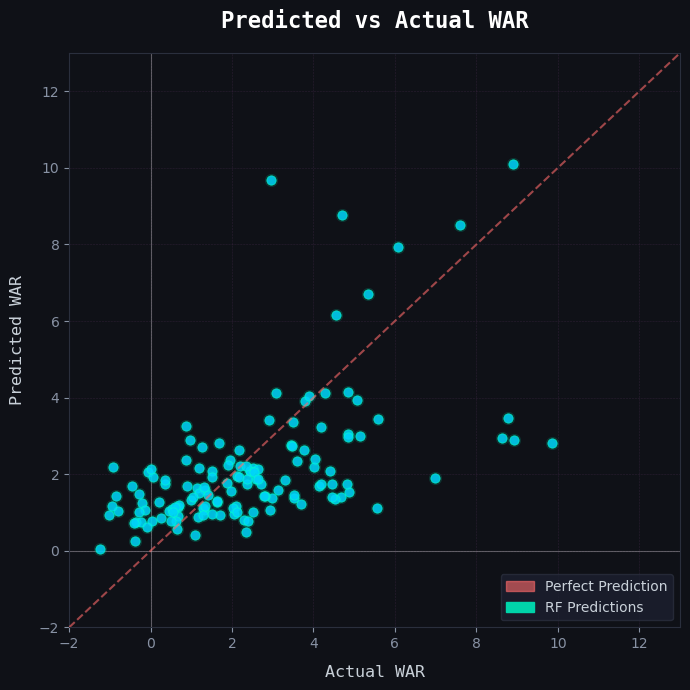

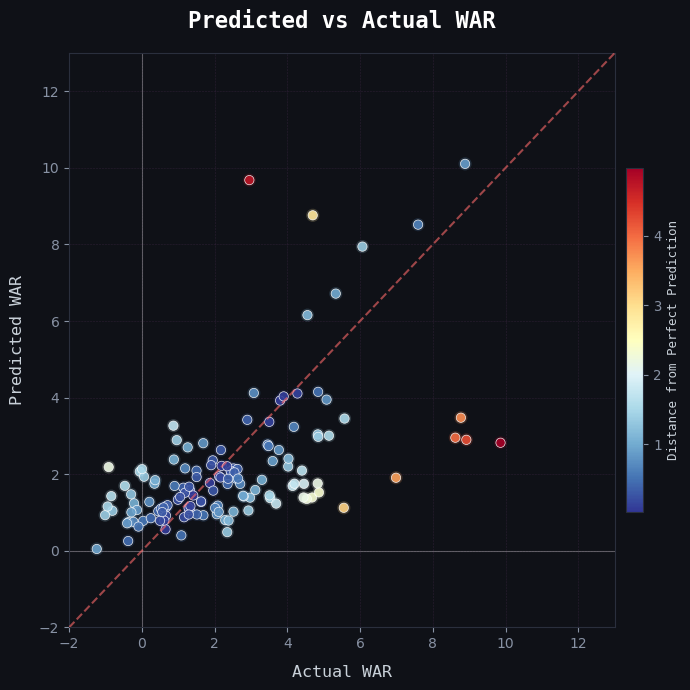

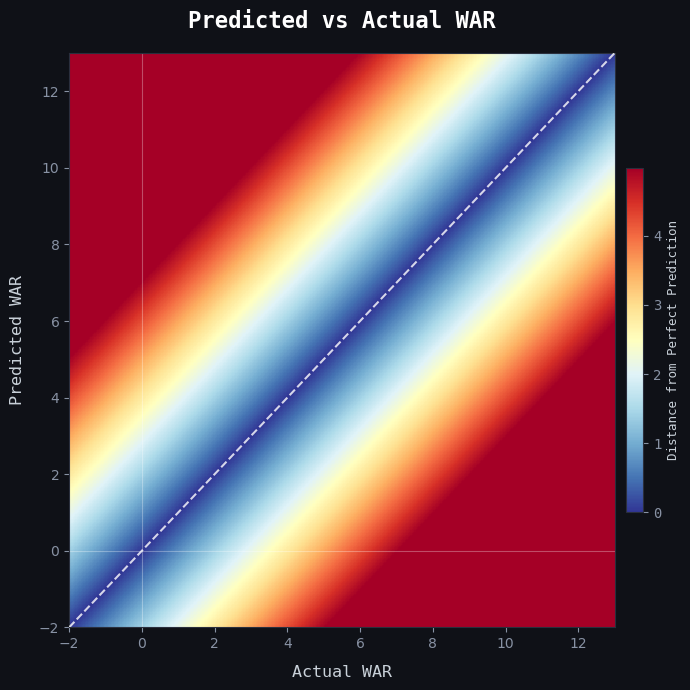

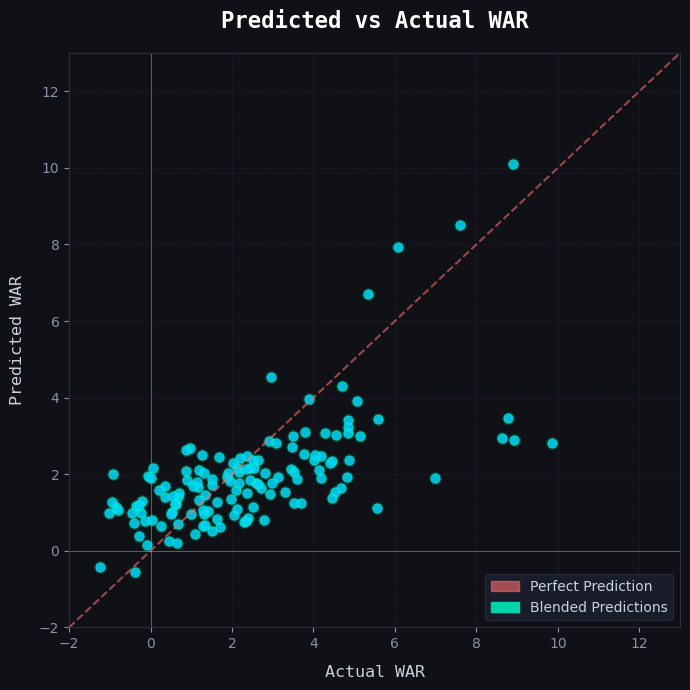

In [33]:
if __name__ == "__main__":

    raw = load_batting_data(start_year=2015, end_year=2023, min_pa=200)
    data = engineer_features(raw)
    X, y, df_clean = prepare_dataset(data)
    test_season = df_clean["Season"].max()
    X_trn, X_tst, y_trn, y_tst = temporal_split(
        X, y, df_clean, test_season=test_season
    )
    ##Run models
    ridge_model, ridge_preds, ridge_metrics, ridge_pred_filt, ridge_m_filt = run_ridge(X_trn, X_tst, y_trn, y_tst)
    ridge_model = ridge_models()
    print("Actual WAR range:", y_tst.min(), y_tst.max())
    print("Predicted WAR range:", ridge_preds.min(), ridge_preds.max())
    print("Mean Actual WAR:", np.mean(y_tst))
    print("Mean Predicted WAR:", np.mean(ridge_preds))
    rf_preds, rf_metrics, elites_pred = run_rf(X_trn, X_tst, y_trn, y_tst)
    rf_model = rf_models()
    elite_mask = y_tst >= 5.1
    blended_preds = pd.concat([
        pd.Series(elites_pred[elite_mask.values], index=y_tst[elite_mask].index),   # RF for WAR >= 5.1
        pd.Series(ridge_pred_filt,               index=y_tst[~elite_mask].index)    # Ridge for WAR < 5.1
    ]).sort_index()
    blended_model = blended_models()

